<a href="https://colab.research.google.com/github/Jupiterian/ML-Learning-Portfolio/blob/main/Linear%20Algebra/Eigenvalue_Transformation_Visualizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eigenvalue Transformation Visualizer
This notebook visualizes the linear transformations provided 2x2 matrix and the eigenvalue transformation applied onto the corresponding eigenvectors. Methods and logic build entirely from scratch, although it depends on numpy for the matrix definition.

## 1.1 Import Modules

In [24]:
# Import Modules
import numpy as np
import matplotlib.pyplot as plt
import math

## 1.2 Define class ETV

In [36]:
from matplotlib.patches import Circle
class ETV():
  def compute(self, A):
    # The goal of the compute function is to compute the eigenvalues and eigenvectors of a given 2x2 matrix A.
    # Characteristic polynomial (quadratic)
    a_term = 1
    b_term = -(A[0, 0] + A[1, 1])
    c_term = (A[0, 0] * A[1, 1]) - (A[0, 1] * A[1, 0])
    # solve quadratic via quadratic forlula for eigenvalues
    self.eval1 = (-b_term + math.sqrt(b_term**2 - 4*a_term*c_term))/(2*a_term)
    self.eval2 = (-b_term - math.sqrt(b_term**2 - 4*a_term*c_term))/(2*a_term)

    # Find eigenvectors
    matrix1 = A.copy()
    matrix1[0,0] = matrix1[0,0] - self.eval1
    matrix1[1,1] = matrix1[1,1] - self.eval1

    matrix2 = A.copy()
    matrix2[0,0] = matrix2[0,0] - self.eval2
    matrix2[1,1] = matrix2[1,1] - self.eval2

    # calculate nullspace of matrix1 and matrix2 to find eigenvectors

    c =  (-matrix1[0, 1])/(matrix1[0,0])
    self.evector1 = np.array([[c], [1]])
    d =  (-matrix2[0, 1])/(matrix2[0,0])
    self.evector2 = np.array([[d], [1]])
  def visualize(self, A):
    fig, ax = plt.subplots()
    circle = plt.Circle(xy=(0,0), radius=1, fill=False)
    ax.add_patch(circle)
    v1 = self.evector1.flatten()
    v2 = self.evector2.flatten()
    ax.plot([0, v1[0]],
            [0, v1[1]],
            label="Eigenvector 1")

    ax.plot([0, v2[0]],
            [0, v2[1]],
            label="Eigenvector 2")
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()

    fig1, ax1 = plt.subplots()
    determinant = (A[0,0] * A[1, 1]) - (A[0, 1] * A[1, 0])
    circle = plt.Circle(xy=(0,0), radius=determinant, fill=False)
    ax1.add_patch(circle)
    v1M = self.eval1 * v1
    v2M = self.eval2 * v2
    ax1.plot([0, v1M[0]],
            [0, v1M[1]],
            label="Eigenvector 1 Tranformed")

    ax1.plot([0, v2M[0]],
            [0, v2M[1]],
            label="Eigenvector 2 Transformed")
    ax1.set_aspect('equal')
    ax1.grid(True)
    ax1.legend()
    plt.show()

## 1.3 Testing

8.0
-1.0
[[1.]
 [1.]]
[[-0.28571429]
 [ 1.        ]]


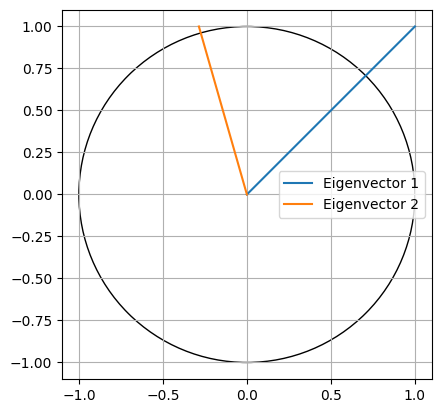

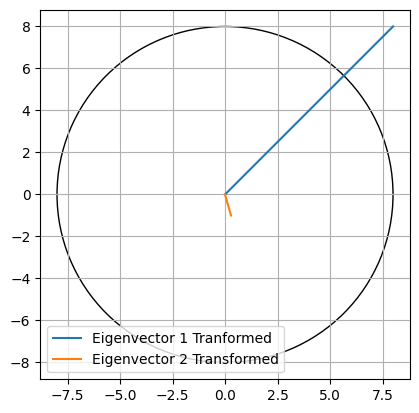

EigResult(eigenvalues=array([ 8., -1.]), eigenvectors=array([[ 0.70710678, -0.27472113],
       [ 0.70710678,  0.96152395]]))


In [35]:
# Testing
X = np.array([[6, 2], [7, 1]])
abc = ETV()
abc.compute(X)
print(abc.eval1)
print(abc.eval2)
print(abc.evector1)
print(abc.evector2)
abc.visualize(X)